# Breast Cancer Prediction Pipeline

This notebook implements the main pipeline for breast cancer classification using RNA-Seq data. It includes data loading and preprocessing, statistical feature selection (ANOVA F-test), dimensionality reduction (PCA), and classification using a Random Forest model.

## Setup and Configuration

This step sets up the required libraries and defines the folder structure used in this notebook. The data is organized into four main folders under `data/`:
- `raw/`: Raw downloaded files (e.g., GTEx `.gct`, GDC `.tsv`).
- `initial/`: Processed raw files (e.g., merged and transposed).
- `interim/`: Feature-selected or partially transformed files.
- `processed/`: Final model-ready inputs (e.g., PCA-reduced features).

In [2]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import shutil
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, permutation_test_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Define data folder structure
DATA_DIR = "data"
RAW_GDC_DIR = os.path.join(DATA_DIR, "raw_gdc_data")
RAW_GTX_DIR = os.path.join(DATA_DIR, "raw_gtx_data")

INITIAL_DIR = os.path.join(DATA_DIR, "initial")
INTERIM_DIR = os.path.join(DATA_DIR, "interim")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")

MODELS_DIR = "models"
REPORTS_DIR = "reports"

In [4]:
# Create directories if they don't exist
os.makedirs(INITIAL_DIR, exist_ok=True)
os.makedirs(INTERIM_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

### Step 1: Initial Process of GDC Raw Sample Files

This block processes RNA-Seq files downloaded from the GDC portal. Each `.tsv` file contains gene expression data for a single cancer sample. From each file, the column `tpm_unstranded` is extracted, indexed by `gene_id`.

These per-sample files are merged into a single matrix where:
- **Rows** = genes,
- **Columns** = samples,
- **Values** = TPM expression values.

This process results in a file `gdc_data.csv` saved to the `data/initial/` folder. 

It is computationally expensive, so it is designed to be skipped once completed unless the raw data changes.

#### Step 1.1
Merging separate cancer sample files and Building a complete dataset file

In [ ]:
# Define paths for GDC sample sheet and data files
gdc_sample_sheet_path = os.path.join(RAW_GDC_DIR, 'gdc_sample_sheet.tsv')
gdc_merged_file_path = os.path.join(INITIAL_DIR, 'gdc_data.csv')

In [ ]:
sample_sheet_file_handler = pd.read_csv(gdc_sample_sheet_path, sep='\t')

# Initialize an empty DataFrame to store the combined data
gdc_df = pd.DataFrame()

sample_counter = 1
# Iterate through each file listed in the sample sheet
for index, row in sample_sheet_file_handler.iterrows():
    folder_id = row['File ID']
    file_name = row['File Name']
    
    # Construct the full file path
    sample_file_path = os.path.join(RAW_GDC_DIR, folder_id, file_name)
    
    # Read the TSV file
    try:
        sample_data = pd.read_csv(sample_file_path, sep='\t', skiprows=[0, 2, 3, 4, 5])
        
        # Extract the relevant columns ('gene_id' and 'TPM' or equivalent)
        relevant_data = sample_data[['gene_id', 'tpm_unstranded']]
        
        # Rename the columns to match the GTex format
        sample_number = 'c_' + str(sample_counter).zfill(4)
        relevant_data.columns = ['gene_id', sample_number]  # Use folder_id as the sample name
        
        # Merge with the combined data
        if gdc_df.empty:
            gdc_df = relevant_data
        else:
            gdc_df = pd.merge(gdc_df, relevant_data, on='gene_id', how='outer')

        sample_counter += 1
            
    except Exception as e:
        print(f"Error processing file {sample_file_path}: {e}")

gdc_df.to_csv(gdc_merged_file_path, index=False)

In [ ]:
# Load and display the first few rows of the merged GDC dataset
gdc_merged_file_path = os.path.join(INITIAL_DIR, 'gdc_data.csv')

gdc_merged_file_df = pd.read_csv(gdc_merged_file_path, index_col=0)
print("Shape of initial GDC Data Set", gdc_merged_file_df.shape)
gdc_merged_file_df.head(5)

#### Step 1.2
Building a model training dataset of 1000 samples and an unseen dataset of 231 samples for testing fo deploying model

In [8]:
# Define path
gdc_data_file_path = os.path.join(INITIAL_DIR, 'gdc_data.csv')

gdc_df = pd.read_csv(gdc_data_file_path, nrows=5)
columns = gdc_df.columns.tolist()

gene_info_columns = columns[0:1]
tpm_columns = columns[1:]

# Randomly select 1000 sample columns from the dataset as traiing data
chosen_columns_for_training = np.random.choice(tpm_columns, 1000, replace=False).tolist()
final_columns_for_training = gene_info_columns + chosen_columns_for_training

# Get the remaining columns as testing data
chosen_columns_for_testing = [col for col in tpm_columns if col not in chosen_columns_for_training]
final_columns_for_testing = gene_info_columns + chosen_columns_for_testing

# Load the dataset again but only with the selected columns
gdc_1000_df = pd.read_csv(gdc_data_file_path, usecols=final_columns_for_training)
gdc_231_df = pd.read_csv(gdc_data_file_path, usecols=final_columns_for_testing)

# Save the training and testing data to new files
gdc_training_file_path = os.path.join(INITIAL_DIR, 'gdc_data_training.csv')
gdc_testing_file_path = os.path.join(INITIAL_DIR, 'gdc_data_testing.csv')

gdc_1000_df.to_csv(gdc_training_file_path, index=False)
gdc_231_df.to_csv(gdc_testing_file_path, index=False)

In [9]:
print("Shape of initial GDC Training Data Set", gdc_1000_df.shape)
gdc_1000_df.head(5)

Shape of initial GDC Training Data Set (60660, 1001)


,gene_id,c_0003,c_0005,c_0006,c_0008,c_0009,c_0010,c_0012,c_0013,c_0014,...,c_1218,c_1219,c_1220,c_1221,c_1222,c_1224,c_1227,c_1228,c_1229,c_1230
0,ENSG00000000003.15,90.4249,18.0535,10.6064,63.9724,75.6881,11.2357,42.7436,58.2760,14.1538,...,34.3788,16.2896,84.4328,52.3403,27.3544,30.1448,85.6117,71.7311,5.3684,113.1190
1,ENSG00000000005.6,0.0000,0.3523,0.6661,0.3128,0.3828,0.0000,10.1675,82.3055,0.7384,...,0.6713,0.7410,12.1832,0.2608,0.0979,0.0567,0.3046,0.6878,0.3944,0.4400
2,ENSG00000000419.13,110.8229,71.4260,112.2490,125.0148,111.9771,66.6285,139.8421,90.0477,244.7773,...,290.1744,87.3807,111.7066,107.1986,82.4554,126.5208,148.1734,115.8308,129.9716,82.5384
3,ENSG00000000457.14,31.8373,10.7816,3.3119,15.2346,8.9836,3.8821,21.9184,11.5658,17.6043,...,7.0962,9.2057,22.8129,16.1887,13.8403,29.8414,12.4748,16.0663,27.4784,19.6494
4,ENSG00000000460.17,15.4869,5.0191,3.8493,9.3567,15.2681,2.3710,24.4534,2.7522,8.5800,...,13.0916,1.2480,4.6271,6.7480,4.8875,12.4256,7.6431,4.8100,12.2774,8.9295


In [10]:
print("Shape of initial GDC Testing Data Set", gdc_231_df.shape)
gdc_231_df.head(5)

Shape of initial GDC Testing Data Set (60660, 232)


,gene_id,c_0001,c_0002,c_0004,c_0007,c_0011,c_0017,c_0028,c_0029,c_0031,...,c_1179,c_1193,c_1200,c_1202,c_1207,c_1215,c_1223,c_1225,c_1226,c_1231
0,ENSG00000000003.15,49.6341,12.0296,26.5679,24.0318,13.0708,2.3364,55.0186,151.5213,26.9026,...,25.5770,36.4423,3.2198,68.1033,29.2468,37.6335,16.6648,26.2866,37.7670,11.5596
1,ENSG00000000005.6,9.3826,0.3785,4.0213,1.3877,0.1461,0.1670,1.2034,0.1028,0.0749,...,1.7853,2.4987,0.3770,0.1034,1.9849,0.4165,0.1169,8.9343,0.0000,0.0424
2,ENSG00000000419.13,115.1737,134.9047,86.0077,52.8140,156.3535,110.0601,143.1775,78.0970,107.2379,...,82.4900,111.6525,47.9404,126.2405,87.4715,178.1384,85.6008,63.2222,165.8215,283.6449
3,ENSG00000000457.14,20.1202,15.5758,19.7490,21.4261,11.0466,18.0468,18.0108,5.5250,8.1179,...,17.2799,8.5948,3.3041,17.9539,12.2471,10.5387,12.5955,11.5421,11.6838,17.0290
4,ENSG00000000460.17,6.1859,4.3777,16.9112,4.8368,7.1264,9.8942,20.9883,2.5497,2.7495,...,6.0722,4.3862,0.4893,5.1302,11.4997,5.9564,4.9241,4.6340,7.6037,8.8565


### Step 2: Initial Process of GTEx Raw Sample Files

This step processes transcriptomic data from GTEx. The original file is in `.gct` format and includes expression levels for thousands of genes across thousands of samples.

This step includes:
1. **Conversion of `.gct` to `.csv`**, skipping initial metadata rows.
2. **Random sampling of 1000 columns (samples)** to ensure balance with the GDC dataset.
3. Saving the final dataset as `gtx_data.csv` in `data/initial/`.

Like GDC, this step is time-consuming and should be skipped in repeated runs unless data needs to be refreshed.

In [ ]:
# Define paths
gtx_17K_gct_file_path = os.path.join(RAW_GTX_DIR, 'gtx_raw_data.gct')
gtx_17K_csv_file_path = os.path.join(RAW_GTX_DIR, 'gtx_raw_data.csv')

##### Step 2.1: Convert GCT to CSV
This block defines the `read_gct()` function, which skips the top two header lines from the `.gct` file and loads the remaining expression matrix into a DataFrame. The `convert_gct_to_csv()` function wraps this logic and saves the result as a temporary `.csv` file.

In [ ]:
def read_gct(file_path):
    with open(file_path, 'r') as f:
        # Skip the first two header lines
        for _ in range(2):
            next(f)
        # Read the rest of the file into a pandas DataFrame
        df = pd.read_csv(f, sep='\t')
    return df

In [ ]:
def convert_gct_to_csv(gct_file, csv_file):
    df = read_gct(gct_file)
    df.to_csv(csv_file, index=False)

In [ ]:
convert_gct_to_csv(gtx_17K_gct_file_path, gtx_17K_csv_file_path)

In [11]:
# Define path
gtx_17K_csv_file_path = os.path.join(RAW_GTX_DIR, 'gtx_raw_data.csv')
gtx_data_file_path = os.path.join(INITIAL_DIR, 'gtx_data.csv')

In [ ]:
gtx_17K_df = pd.read_csv(gtx_17K_csv_file_path, nrows=5)
columns = gtx_17K_df.columns.tolist()

# The first two columns are 'Name' and 'Description', we keep them and sample the rest
gene_info_columns = columns[0:2]
sample_columns = columns[2:]

# Randomly select 1000 sample columns from the dataset as traiing data
chosen_1231_columns = np.random.choice(sample_columns, 1231, replace=False).tolist()
final_1231_columns = gene_info_columns + chosen_1231_columns

# Load the dataset again but only with the selected columns
gtx_1231_df = pd.read_csv(gtx_17K_csv_file_path, usecols=final_1231_columns)
gtx_1231_df = gtx_1231_df.rename(columns={'Name': 'gene_id'})
gtx_1231_df = gtx_1231_df.drop('Description', axis=1)

# Changing the sample ids to h_xxxx format
num_samples = gtx_1231_df.shape[1] - 1
new_sample_names = [f"h_{i:04d}" for i in range(1, num_samples + 1)]
gtx_1231_df.columns = [gtx_1231_df.columns[0]] + new_sample_names


# Save the sampled data to a new CSV file
gtx_1231_df.to_csv(gtx_data_file_path, index=False)

In [12]:
# Load and display the first few rows of the GTex dataset
gtx_data_df = pd.read_csv(gtx_data_file_path, index_col=0)
print("Shape of initial GTex Data Set", gtx_data_df.shape)
gtx_data_df.head(5)

Shape of initial GTex Data Set (56200, 1231)


,h_0001,h_0002,h_0003,h_0004,h_0005,h_0006,h_0007,h_0008,h_0009,h_0010,...,h_1222,h_1223,h_1224,h_1225,h_1226,h_1227,h_1228,h_1229,h_1230,h_1231
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972.5,0.00000,0.00000,0.0000,0.0000,0.00,0.000,0.000,0.01863,0.000,0.05003,...,0.00,0.02168,0.000,0.00000,0.0000,0.000,0.00000,0.00000,0.00000,0.00000
ENSG00000227232.5,4.20000,1.69200,2.7940,3.2010,1.25,1.824,4.206,0.77600,3.248,5.99300,...,17.73,1.94800,9.084,5.05600,0.3865,5.317,5.96800,1.55200,3.86500,2.46600
ENSG00000278267.1,0.00000,0.00000,0.6737,0.5898,0.00,0.000,0.000,0.00000,0.000,0.00000,...,0.00,0.00000,0.000,0.00000,0.0000,0.000,0.00000,0.00000,0.00000,0.00000
ENSG00000243485.5,0.04183,0.09264,0.0000,0.0000,0.00,0.000,0.000,0.00000,0.000,0.00000,...,0.00,0.04328,0.000,0.06862,0.0000,0.000,0.02164,0.03661,0.04819,0.00000
ENSG00000237613.2,0.00000,0.00000,0.0000,0.0000,0.00,0.000,0.000,0.00000,0.000,0.03548,...,0.00,0.00000,0.000,0.00000,0.0000,0.000,0.00000,0.00000,0.00000,0.05597


##### Step 2.2: Randomly sample 1000 columns (samples)
This block randomly selects 1000 GTEx samples (columns) from the large CSV file produced in the previous step. Only gene identifiers and the selected samples are retained. The resulting matrix is saved to `data/initial/gtx_data.csv`.

In [13]:
gtx_data_df = pd.read_csv(gtx_data_file_path, nrows=5)
columns = gtx_data_df.columns.tolist()

# The first two columns are 'Name' and 'Description', we keep them and sample the rest
gene_info_columns = columns[0:1]
tpm_columns = columns[1:]

# Randomly select 1000 sample columns from the dataset as traiing data
chosen_columns_for_training = np.random.choice(tpm_columns, 1000, replace=False).tolist()
final_columns_for_training = gene_info_columns + chosen_columns_for_training

# Randomly select 231 sample columns from the dataset as traiing data
chosen_columns_for_testing = [col for col in tpm_columns if col not in chosen_columns_for_training]
# remaining_columns = [col for col in tpm_columns if col not in chosen_columns_for_training]
# chosen_columns_for_testing = np.random.choice(remaining_columns, 231, replace=False).tolist()
final_columns_for_testing = gene_info_columns + chosen_columns_for_testing

# Load the dataset again but only with the selected columns
gtx_1000_df = pd.read_csv(gtx_data_file_path, usecols=final_columns_for_training)
# gtx_1000_df = gtx_1000_df.rename(columns={'Name': 'gene_id'})
# gtx_1000_df = gtx_1000_df.drop('Description', axis=1)

gtx_231_df = pd.read_csv(gtx_data_file_path, usecols=final_columns_for_testing)
# gtx_231_df = gtx_231_df.rename(columns={'Name': 'gene_id'})
# gtx_231_df = gtx_231_df.drop('Description', axis=1)

# Save the sampled data to a new CSV file
gtx_training_file_path = os.path.join(INITIAL_DIR, 'gtx_data_training.csv')
gtx_testing_file_path = os.path.join(INITIAL_DIR, 'gtx_data_testing.csv')

gtx_1000_df.to_csv(gtx_training_file_path, index=False)
gtx_231_df.to_csv(gtx_testing_file_path, index=False)


In [14]:
print("Shape of initial Gtex Training Data Set", gtx_1000_df.shape)
gtx_1000_df.head(5)

Shape of initial Gtex Training Data Set (56200, 1001)


,gene_id,h_0001,h_0002,h_0003,h_0004,h_0005,h_0006,h_0007,h_0009,h_0010,...,h_1220,h_1221,h_1222,h_1224,h_1225,h_1226,h_1227,h_1228,h_1230,h_1231
0,ENSG00000223972.5,0.00000,0.00000,0.0000,0.0000,0.00,0.000,0.000,0.000,0.05003,...,0.00000,0.0000,0.00,0.000,0.00000,0.0000,0.000,0.00000,0.00000,0.00000
1,ENSG00000227232.5,4.20000,1.69200,2.7940,3.2010,1.25,1.824,4.206,3.248,5.99300,...,8.97900,17.7600,17.73,9.084,5.05600,0.3865,5.317,5.96800,3.86500,2.46600
2,ENSG00000278267.1,0.00000,0.00000,0.6737,0.5898,0.00,0.000,0.000,0.000,0.00000,...,0.00000,0.0000,0.00,0.000,0.00000,0.0000,0.000,0.00000,0.00000,0.00000
3,ENSG00000243485.5,0.04183,0.09264,0.0000,0.0000,0.00,0.000,0.000,0.000,0.00000,...,0.06434,0.0531,0.00,0.000,0.06862,0.0000,0.000,0.02164,0.04819,0.00000
4,ENSG00000237613.2,0.00000,0.00000,0.0000,0.0000,0.00,0.000,0.000,0.000,0.03548,...,0.00000,0.0000,0.00,0.000,0.00000,0.0000,0.000,0.00000,0.00000,0.05597


In [15]:
print("Shape of initial GTex Testing Data Set", gtx_231_df.shape)
gtx_231_df.head(5)

Shape of initial GTex Testing Data Set (56200, 232)


,gene_id,h_0008,h_0011,h_0015,h_0017,h_0026,h_0028,h_0036,h_0040,h_0042,...,h_1185,h_1186,h_1189,h_1191,h_1204,h_1213,h_1215,h_1218,h_1223,h_1229
0,ENSG00000223972.5,0.01863,0.000,0.06809,0.02568,0.06413,0.02417,0.01527,0.00000,0.00000,...,0.02235,0.000,0.02586,0.01897,0.04841,0.000,0.00,0.000,0.02168,0.00000
1,ENSG00000227232.5,0.77600,4.116,2.09800,4.81400,7.43100,4.59400,2.00800,1.68800,4.37100,...,4.30600,11.030,1.61600,4.09900,3.06700,8.895,3.37,1.455,1.94800,1.55200
2,ENSG00000278267.1,0.00000,0.000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.000,0.00000,0.00000,0.00000,0.000,0.00,0.000,0.00000,0.00000
3,ENSG00000243485.5,0.00000,0.000,0.04532,0.05126,0.08535,0.00000,0.06097,0.00000,0.00000,...,0.04462,0.105,0.00000,0.03787,0.00000,0.000,0.00,0.000,0.04328,0.03661
4,ENSG00000237613.2,0.00000,0.038,0.00000,0.00000,0.00000,0.00000,0.04331,0.01559,0.03871,...,0.03170,0.000,0.00000,0.00000,0.00000,0.000,0.00,0.000,0.00000,0.00000


### Step 3: Merge and Label Cancer and Non-Cancer Data

This step merges the GTEx (non-cancer) and GDC (cancer) RNA-Seq datasets and prepares them for machine learning. The goal is to align the gene expression profiles from both sources, assign binary labels, and generate a unified dataset.

This step includes:
1. **Loads**:
   - `gtx_data.csv` and `gdc_data.csv` from `data/initial/`
2. **Aligns gene features** (columns) to keep only shared genes between GTEx and GDC.
3. **Transposes the matrices**:
   - Each **row** becomes a sample,
   - Each **column** is a gene (TPM value).
4. **Assigns labels**:
   - `0` for GTEx (healthy samples),
   - `1` for GDC (cancer samples).
5. **Combines** both datasets into a single feature matrix and a corresponding label vector.

##### Output files (in `data/interim/`):
- `preprocessed_data_features.csv`: Combined matrix of all samples with aligned gene features (samples × genes)
- `preprocessed_data_labels.csv`: Binary labels for each sample (0 = GTEx, 1 = GDC)

These files serve as input to the next steps: statistical feature selection and dimensionality reduction.


In [25]:
def merge_data(gtx_file_path, gdc_file_path):    

    # Load the datasets with headers
    gtx__df = pd.read_csv(gtx_file_path, header=0)
    gdc__df = pd.read_csv(gdc_file_path, header=0)

    # Ensure that the 'gene_id' column is the index for both datasets
    gtx__df.set_index('gene_id', inplace=True)
    gdc__df.set_index('gene_id', inplace=True)

    # Add labels row: 0 for GTEx (healthy) and 1 for GDC (cancer)
    gtx_labels = pd.DataFrame([0] * gtx__df.shape[1], index=gtx__df.columns, columns=['label']).transpose()
    gdc_labels = pd.DataFrame([1] * gdc__df.shape[1], index=gdc__df.columns, columns=['label']).transpose()

    # Concatenate labels and data
    gtx__df = pd.concat([gtx_labels, gtx__df])
    gdc__df = pd.concat([gdc_labels, gdc__df])

    # Combine both datasets
    combined_data = pd.concat([gtx__df, gdc__df], axis=1)

    # Transpose the data to have samples as rows and genes as columns
    combined_data = combined_data.transpose()

    # Separate features and labels
    labels = combined_data['label']
    features = combined_data.drop(columns=['label'])

    # Save preprocessed features and labels to CSV
    output_file_prefix = os.path.join(INTERIM_DIR, 'training_data')
    features.to_csv(output_file_prefix + '_features.csv', index=False)
    labels.to_csv(output_file_prefix + '_labels.csv', index=False)

    print("Data Merging Complete")
    print("Shape of features:", features.shape)
    print("Shape of labels:", labels.shape)

In [26]:
gtx_data_file = os.path.join(INITIAL_DIR, 'gtx_data_training.csv')
gdc_data_file = os.path.join(INITIAL_DIR, 'gdc_data_training.csv')

merge_data(gtx_data_file, gdc_data_file)

Data Merging Complete
Shape of features: (2000, 81743)
Shape of labels: (2000,)


### Step 4: Statistical Feature Selection using ANOVA F-test

This step applies a univariate statistical method — the ANOVA F-test — to select the most informative gene features for classification. It is a standard approach for high-dimensional data such as RNA-Seq, where the number of features (genes) far exceeds the number of samples.

This step includes:
1. **Loads**:
   - The combined feature matrix from `data/interim/preprocessed_data_features.csv`
   - The label vector from `data/interim/preprocessed_data_labels.csv`
2. Applies **ANOVA F-test** using `SelectKBest` from `scikit-learn` to select the top 1000 gene features that show the most variation between the cancer and non-cancer classes.
3. Saves the reduced feature matrix for downstream use.

##### Output:
- `selected_features.csv` (in `data/interim/`): A reduced feature matrix with shape (samples × 1000)

This step dramatically reduces the feature space from ~60,000 genes to 1000, making subsequent modeling steps more efficient and less prone to overfitting.


In [27]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer

def remove_constant_features(features):
    """Remove constant features from the dataset."""
    selector = VarianceThreshold()
    return selector.fit_transform(features), selector.get_support(indices=True)

def statistical_feature_selection(features_file, labels_file, output_file, k=1000):
    # Load preprocessed features and labels
    features = pd.read_csv(features_file)
    labels = pd.read_csv(labels_file)

    # Handle NaN values by imputing with the mean
    imputer = SimpleImputer(strategy='mean')
    features_imputed = imputer.fit_transform(features)

    # Remove constant features
    features_imputed, selected_indices = remove_constant_features(features_imputed)
    feature_names = features.columns[selected_indices]

    # Perform feature selection
    selector = SelectKBest(f_classif, k=k)
    selected_features = selector.fit_transform(features_imputed, labels['label'])

    # Get selected feature names
    feature_names = feature_names[selector.get_support()]
    selected_features_df = pd.DataFrame(selected_features, columns=feature_names)
    
    # Save the selected features to the output file
    selected_features_df.to_csv(output_file, index=False)

    print("Statistical Feature Selection Complete")
    print("Shape of selected features:", selected_features_df.shape)

In [28]:
features_file = os.path.join(INTERIM_DIR, 'training_data_features.csv')
labels_file = os.path.join(INTERIM_DIR,'training_data_labels.csv')
output_file = os.path.join(INTERIM_DIR, 'training_data_selected_features.csv')

statistical_feature_selection(features_file, labels_file, output_file)

Statistical Feature Selection Complete
Shape of selected features: (2000, 1000)


In [29]:
label_file_in_interim = os.path.join(INTERIM_DIR, 'training_data_labels.csv')
label_file_in_processed = os.path.join(PROCESSED_DIR, 'labels.csv')

# Copy the label file into the "processed" folder 
shutil.copyfile(label_file_in_interim, label_file_in_processed)

'data/processed/labels.csv'

### Step 5: Dimensionality Reduction using PCA

After statistical feature selection, this step applies Principal Component Analysis (PCA) to further reduce the dimensionality of the data. PCA projects the 1000 selected gene features into a lower-dimensional space while preserving as much variance as possible.

This step includes:
1. **Loads**:
   - The 1000-gene feature matrix from `data/interim/selected_features.csv`
2. Applies **PCA** to reduce the feature space to 50 principal components.
3. Transforms the dataset into the reduced space and saves it.

##### Output:
- `pca_reduced_features.csv` (in `data/processed/`): A feature matrix with shape (samples × 50), ready for training classifiers.

PCA helps compress the dataset, reduce noise, and improve the stability and performance of machine learning models in high-dimensional settings like genomics.


In [30]:
def dimensionality_reduction(selected_features_file, output_file, n_components=50):
    # Load selected features
    selected_features = pd.read_csv(selected_features_file)

    # Perform PCA
    pca = PCA(n_components=n_components)
    reduced_features = pca.fit_transform(selected_features)

    # Create a DataFrame with reduced features
    reduced_features_df = pd.DataFrame(reduced_features, columns=[f'PC{i+1}' for i in range(n_components)])
    
    # Save the reduced features to the output file
    reduced_features_df.to_csv(output_file, index=False)

    print("Dimensionality Reduction Complete")
    print("Shape of reduced features:", reduced_features_df.shape)

In [31]:
n_components = 50
selected_features_file = os.path.join(INTERIM_DIR, 'training_data_selected_features.csv')
output_file = os.path.join(PROCESSED_DIR, 'features.csv')

dimensionality_reduction(selected_features_file, output_file, n_components)

Dimensionality Reduction Complete
Shape of reduced features: (2000, 50)


Create the following files the `processed` folder:

These data sets contains training data with 50 PCs, which will be used for model training and cross validation:

- `dataset.csv`: a complete training dataset of both cancer (1000 samples) and non-cancer (1000 samples) with their labels
- `benign.csv`: only non-cancer data (1000 samples) with their labels
- `cancer.csv`: only cancer data (1000 samples) with their labels

In [33]:
labels_file_path = os.path.join(PROCESSED_DIR, 'labels.csv')
features_file_path = os.path.join(PROCESSED_DIR, 'features.csv')

labels_df = pd.read_csv(labels_file_path)
features_df = pd.read_csv(features_file_path)

dataset_df = pd.concat([features_df, labels_df], axis=1)
dataset_df.to_csv(os.path.join(PROCESSED_DIR, 'dataset.csv'), index=False)

benign_dataset = dataset_df[dataset_df['label'] == 0]
benign_dataset.to_csv(os.path.join(PROCESSED_DIR, 'benign.csv'), index=False)

cancer_dataset = dataset_df[dataset_df['label'] == 1]
cancer_dataset.to_csv(os.path.join(PROCESSED_DIR, 'cancer.csv'), index=False)

### Step 6: Classification with Random Forest and Evaluation

This step trains a machine learning classifier to distinguish between cancer and non-cancer samples using the PCA-reduced feature matrix.

A **Random Forest** classifier is used due to its robustness, interpretability, and suitability for high-dimensional biological data. Evaluation is done using **5-fold Stratified Cross-Validation** to ensure balanced class representation in each fold.

This step includes:
1. **Loads**:
   - PCA-reduced feature matrix from `data/processed/pca_reduced_features.csv`
   - Corresponding labels from `data/interim/preprocessed_data_labels.csv`
2. Performs **5-fold Stratified Cross-Validation**, training and testing the Random Forest model on different splits.
3. Computes and stores key performance metrics:
   - Accuracy
   - Precision
   - Recall
   - F1-score

##### Output:
- A printed performance summary for each fold.
- Optionally: confusion matrices and average metric summaries.

This step provides a robust estimate of the model’s generalization performance on unseen data.


In [34]:
def dual_print(file_path, *args):
    message = " ".join(map(str, args))
    
    # Print to console
    print(message)
    
    # Append to file
    with open(file_path, 'a') as file:
        file.write(message + '\n')

In [35]:
def cross_validate_model(features_file, labels_file, model_file_prefix, report_file, num_splits=5, n_permutations=100):
    
    # Load data
    X = pd.read_csv(features_file)
    y = pd.read_csv(labels_file).values.ravel()

    # Stratified K-Fold Cross-Validation
    skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=42)
    accuracies, precisions, recalls, f1_scores = [], [], [], []
    confusion_matrices = []

    fig_cm = plt.figure(figsize=(12, 6), dpi=300, constrained_layout=False)
    gs = gridspec.GridSpec(2, 6, figure=fig_cm, wspace=3, hspace=0.5)

    model_number = 0
    for train_index, test_index in skf.split(X, y):
        
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model_number += 1
        
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        # Save the model
        model_file = model_file_prefix + str(model_number) + '.pkl'
        with open(model_file, 'wb') as f:
            pickle.dump(model, f)
            
        y_pred = model.predict(X_test)

        accuracies.append(accuracy_score(y_test, y_pred))
        precisions.append(precision_score(y_test, y_pred, zero_division=1))
        recalls.append(recall_score(y_test, y_pred, zero_division=1))
        f1_scores.append(f1_score(y_test, y_pred, zero_division=1))

        # Save confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        confusion_matrices.append(cm)

        # Draw confusion matrices in one plot
        i = model_number - 1
        if i < 3:
            ax = plt.subplot(gs[0, 2 * i:2 * i + 2])
        else:
            ax = plt.subplot(gs[1, 2 * i - 5:2 * i + 2 - 5])
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'Fold {model_number}', fontsize=9, fontweight="bold")
        ax.set_xlabel('Prediction', fontsize = 8, fontweight="bold")
        ax.set_ylabel('Actual', fontsize = 8, fontweight="bold")
        ax.set_xticklabels(['Benign', 'Cancer'], fontsize=7, rotation=0)
        ax.set_yticklabels(['Benign', 'Cancer'], fontsize=7, rotation=90)    

    fig_cm.show()
    
    # Compute averages
    avg_accuracy = sum(accuracies) / num_splits
    avg_precision = sum(precisions) / num_splits
    avg_recall = sum(recalls) / num_splits
    avg_f1_score = sum(f1_scores) / num_splits

    # Log Cross-Validation Results
    dual_print(report_file, f"Cross-Validation Results:")
    dual_print(report_file, f"  Accuracy: {avg_accuracy:.4f}")
    dual_print(report_file, f"  Precision: {avg_precision:.4f}")
    dual_print(report_file, f"  Recall: {avg_recall:.4f}")
    dual_print(report_file, f"  F1 Score: {avg_f1_score:.4f}")

    """
    # Perform Permutation Test
    score, permutation_scores, p_value = permutation_test_score(
        model, X, y, scoring="accuracy", cv=skf, n_permutations=n_permutations, random_state=42)

    # Log Permutation Test Results
    dual_print(report_file, f"Permutation Test Results:")
    dual_print(report_file, f"  Original Model Accuracy: {score:.4f}")
    dual_print(report_file, f"  Mean Permuted Accuracy: {permutation_scores.mean():.4f}")
    dual_print(report_file, f"  p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        dual_print(report_file, "  The model significantly outperforms random chance (p < 0.05).")
    else:
        dual_print(report_file, "  The model's performance is not significantly better than random.")

    # Save final trained model
    with open(f"{model_file_prefix}_random_forest.pkl", "wb") as model_file:
        pickle.dump(model, model_file)
    """
    
    fig_cm.savefig(f"{model_file_prefix}_confusion_matrix.png")


/var/folders/fn/dspxzyfn6_b380rs381r5bn40000gp/T/ipykernel_65680/3677213124.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_cm.show()


Cross-Validation Results:
  Accuracy: 0.9965
  Precision: 0.9950
  Recall: 0.9980
  F1 Score: 0.9965


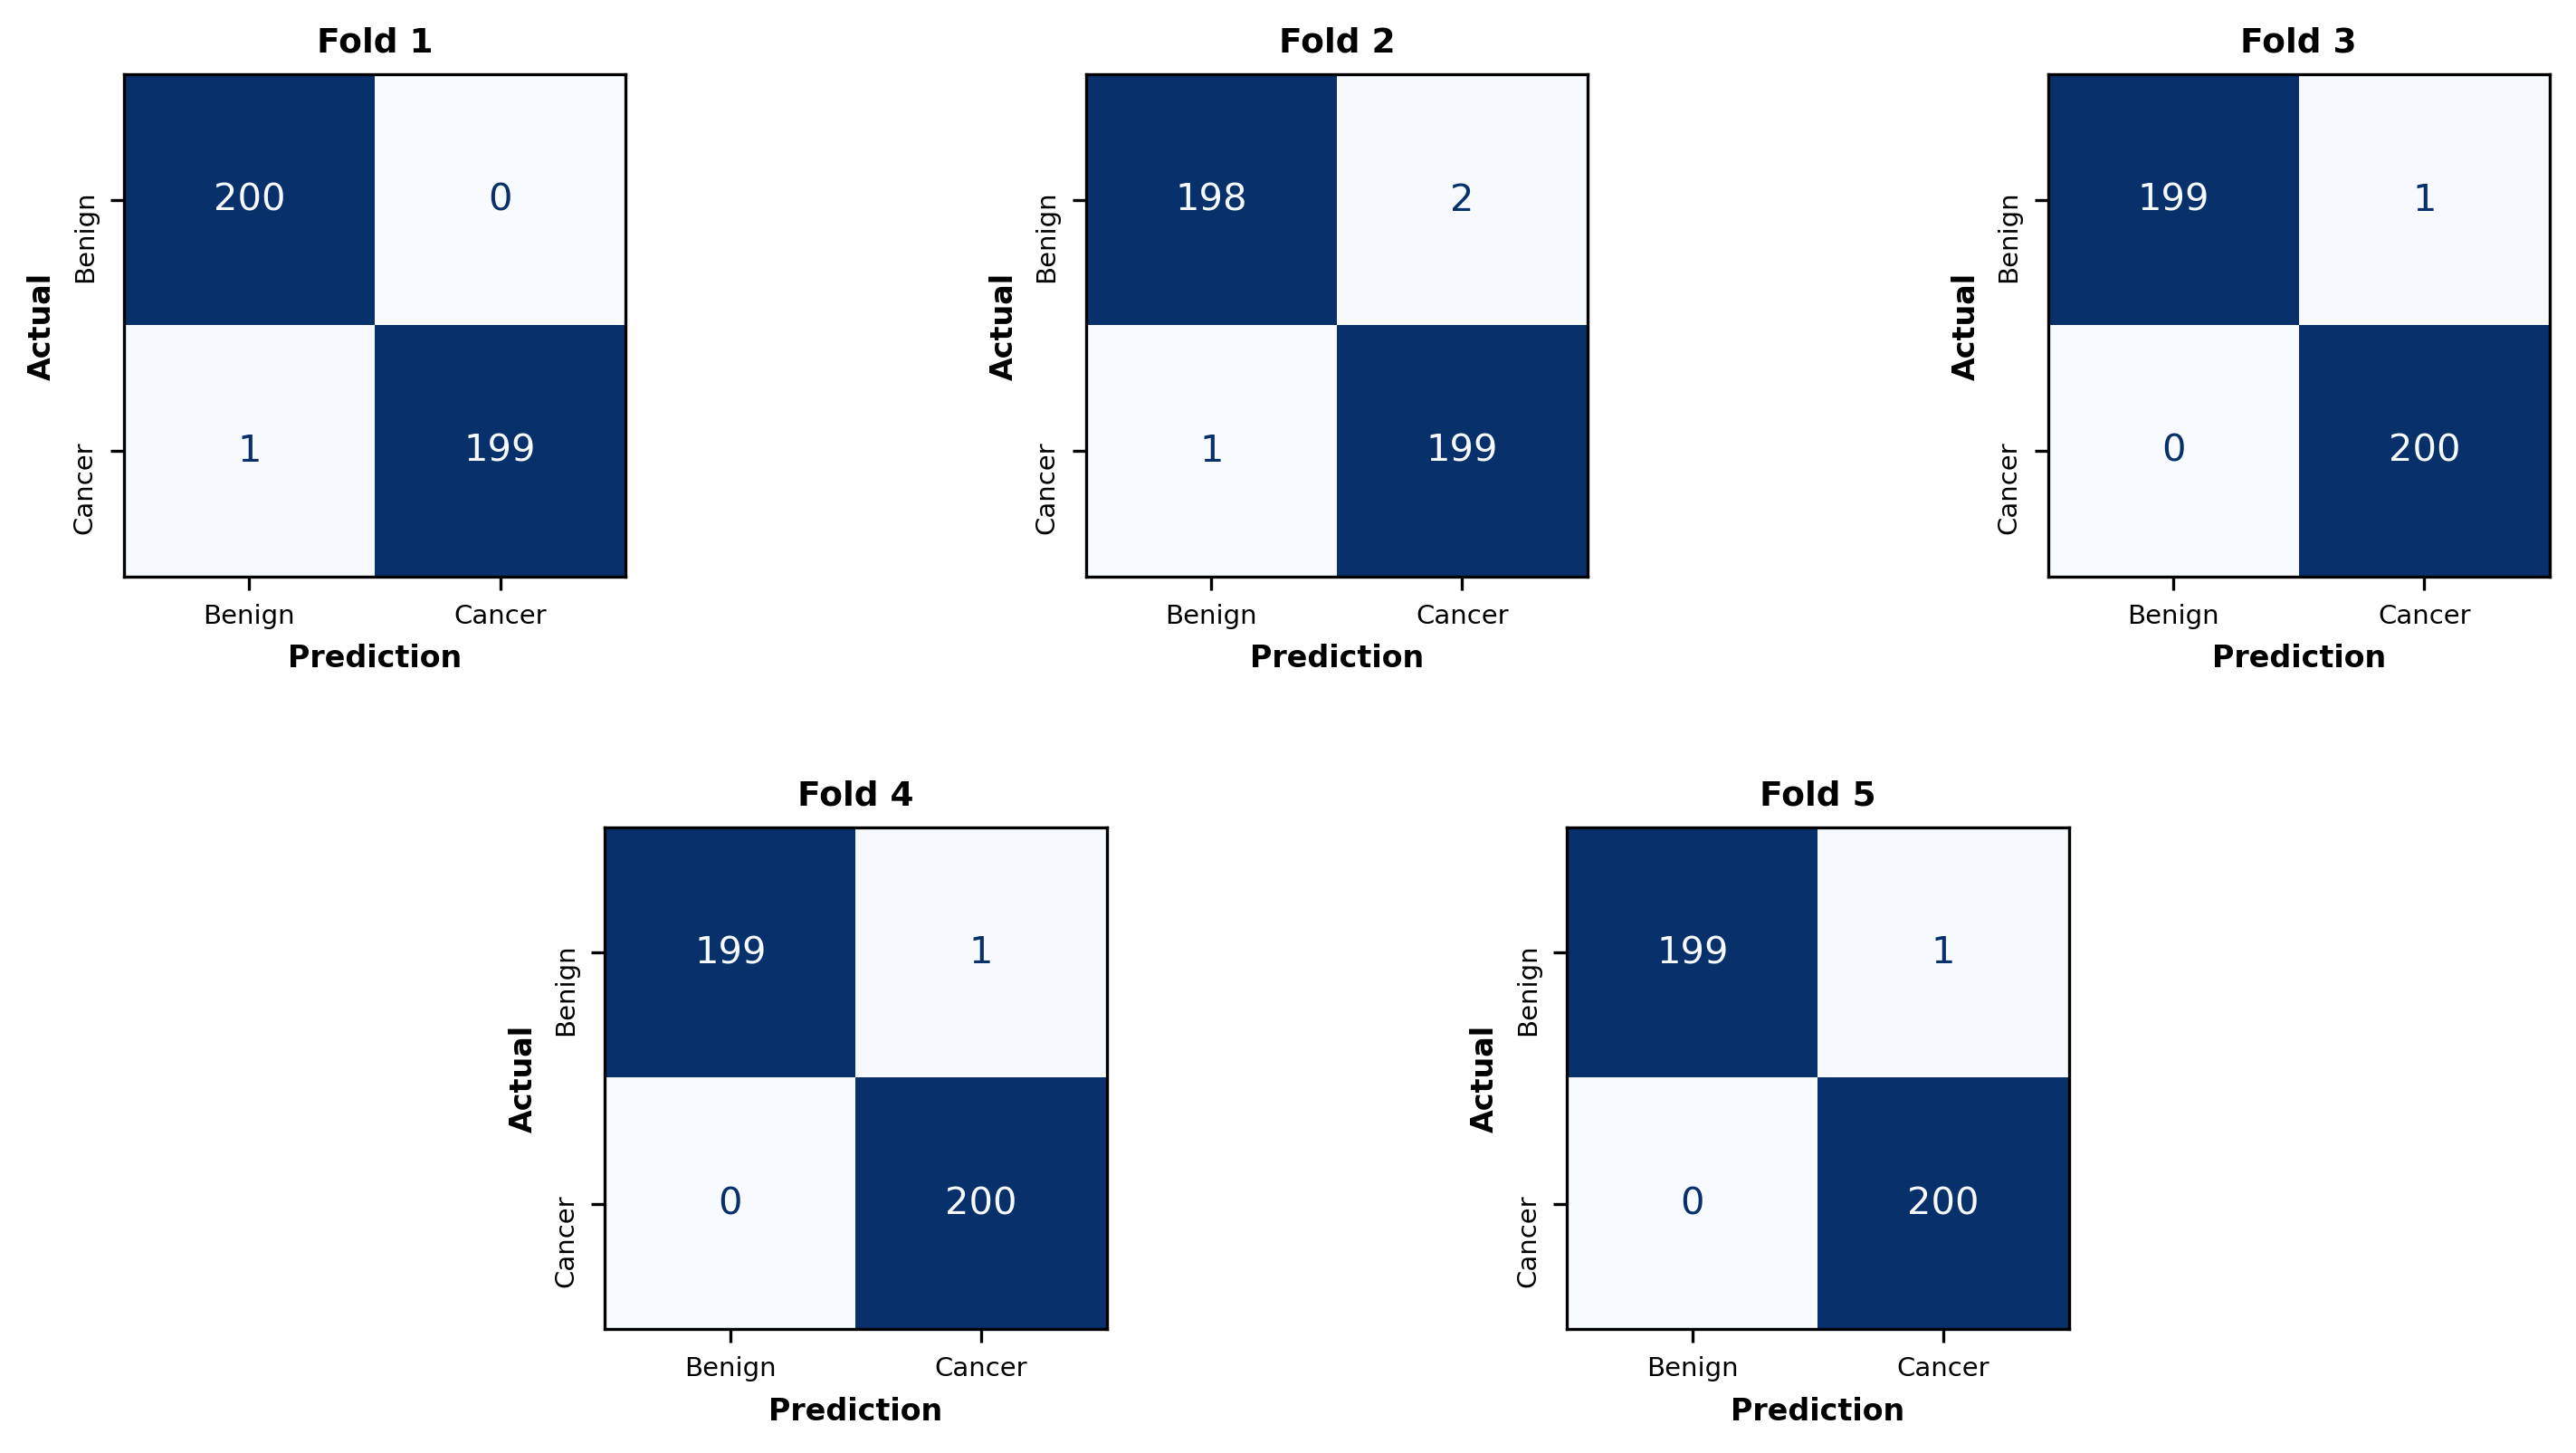

In [36]:
features_file = os.path.join(PROCESSED_DIR, 'features.csv')
labels_file = os.path.join(PROCESSED_DIR, 'labels.csv')

model_file_prefix = os.path.join(MODELS_DIR, 'rfc_model_5F_CV_')
report_file = os.path.join(REPORTS_DIR, 'CV_report.txt')

cross_validate_model(features_file, labels_file, model_file_prefix, report_file,
    num_splits=5, n_permutations=100)

### Step 7: Evaluation Summary and Visualization

This step summarizes and visualizes the performance of the Random Forest classifier across the 5 cross-validation folds. It helps interpret how well the model distinguishes between cancer and non-cancer samples and identifies potential inconsistencies or class imbalances.

This step includes:
1. Displays the **per-fold scores** for Accuracy, Precision, Recall, and F1-score.
2. Computes and prints the **average and standard deviation** for each metric.
3. Optionally visualizes:
   - Metric trends across folds
   - Confusion matrices

#### Output:
- A printed table of metric values per fold
- (Optional) Summary plots or visual outputs

These insights validate the model’s reliability and highlight areas for further tuning or ablation study.


In [ ]:
import pandas as pd
import shap
import pickle

# Load the model
with open('trained_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the data
features = pd.read_csv('reduced_features.csv')

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(features)

# Plot SHAP values for a sample
shap.summary_plot(shap_values, features)